# New For June: We Fold Baryons into the CDM Information for Consistent Cosmology

The Fiducial sigma 8 at current universe is  0.8094303002457167
233.3333282470703
(206, 13)


array([0.00874149])

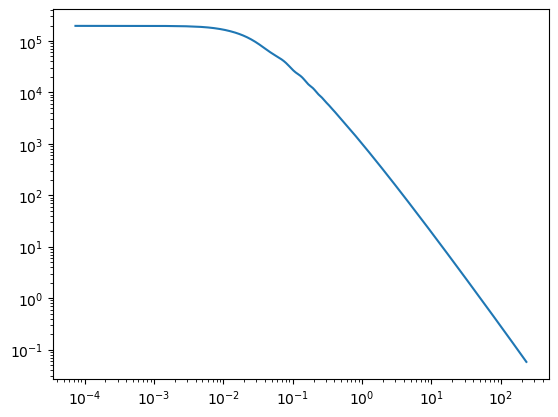

In [1]:
# Doing some extra stuff

import camb

import matplotlib.pyplot as plt
import numpy as np

Cols = ['k/h', 'delta_cdm', 'delta_baryon', 'delta_photon', 'delta_neutrino', 'delta_nu', 'delta_tot', 'delta_nonu', 'delta_tot_de', 'Weyl', 'v_newtonian_cdm', 'v_newtonian_baryon', 'v_baryon_cdm']

zTG = 120

Params = camb.read_ini("/Users/fwphys/AxionResearch/Axionyx_Dev22/_axionCAMB-master/GOE_RUN7/BaseL.ini")

Params.set_matter_power(redshifts=[zTG,0], kmax=150.0)

sigma8 = 0.811
As = 2.0569827048923148e-09

results = camb.get_results(Params)
s8_fid = results.get_sigma8()[1]

print("The Fiducial sigma 8 at current universe is ", s8_fid)

Params.InitPower.set_params(As=As * sigma8**2 / s8_fid**2, ns=0.96)

Params.Transfer.transfer_power_var = 7

# 4. Disable CMB calculations if not needed, for faster execution
Params.WantCls = False
Params.Want_CMB = False
Params.Want_CMB_lensing = False
Params.DoLensing = False
Params.WantTensors = False # If you don't need tensor modes

Params.set_matter_power(redshifts=[zTG], kmax=150.0)

# Run CAMB AGAIN
results = camb.get_results(Params)

kh, z, pk = results.get_matter_power_spectrum(minkh=1e-3, maxkh=150, npoints=200)

transfer = results.get_matter_transfer_data()

MyCAMB = np.float64(transfer.transfer_data[:,:,0].T)


plt.loglog(MyCAMB[:,0],MyCAMB[:,6])
print(np.max(MyCAMB[:,0]))

print(MyCAMB.shape)

results.get_sigma8()

In [2]:
# 
np.savetxt(f"/Volumes/FWS500/AXIONYX_D/Transfer_Functions/z{zTG}/G7_000_000" + '_cdm.dat', MyCAMB, delimiter='\t')

此
233.3333282470703
此
7.407407247228548e-05 233.3333282470703
0.0
Baryon and CDM Averaged!


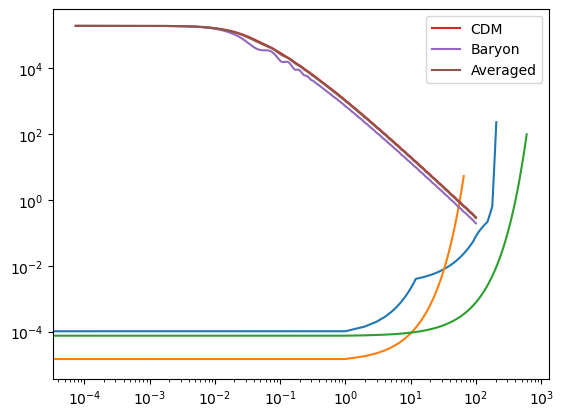

In [8]:
# Transitional Step, Fill New Data into Old Template

from scipy.interpolate import interp1d

data_CAMB = np.loadtxt(f'/Volumes/FWS500/AXIONYX_D/Transfer_Functions/z{zTG}/G7_000_000_cdm.dat') # Example CAMB output of the version compatible with MUSIC
plt.semilogy(data_CAMB[:,0])

print("此")
print(data_CAMB[-1,0])
print("此")

data_CAMB_Stock = np.loadtxt('./example_CAMB_transfer_out.dat') # Example CAMB output of the version compatible with MUSIC
plt.semilogy(data_CAMB_Stock[:,0])


dCS = data_CAMB_Stock
dC = data_CAMB

'''
NewBase = dCS.copy()

for i in range(1,13):
    interp = interp1d(dC[:,0], dC[:,i], bounds_error=False, fill_value=dC[0,i])
    NewBase[:,i] = interp(dCS[:,0])
'''

NumK = 600
NewBase = np.zeros([NumK,13])

MaxK = 100

print(dC[0,0], dC[-1,0])

KArr = np.geomspace(dC[0,0], MaxK, NumK)
NewBase[:,0] = KArr

for i in range(1,13):
    interp = interp1d(dC[:,0], dC[:,i], bounds_error=False, fill_value=dC[0,i])
    NewBase[:,i] = interp(KArr)

    
plt.semilogy(NewBase[:,0])
data_CAMB = NewBase.copy()

np.savetxt(f'/Volumes/FWS500/AXIONYX_D/Transfer_Functions/z{zTG}/G7_000_000_cdm_NB.dat' , data_CAMB, delimiter='\t')

OmM = 0.31
OmB = 0.02222 / 0.675**2

OmDM = OmM - OmB

OmA = 0
OmC = OmDM - OmA

print(OmA / OmM)

BaryonRatio = OmB / (OmC + OmB)

k = data_CAMB[:, 0]
Tkc = data_CAMB[:, 1]
Tkb = data_CAMB[:, 2]
Tktot = data_CAMB[:, 6]

TkPars = Tkc * (1-BaryonRatio) + Tkb * BaryonRatio
plt.loglog(k,Tkc, label = "CDM")
plt.loglog(k,Tkb, label = "Baryon")
plt.loglog(k,TkPars, label = "Averaged")
data_CAMB[:,1] = TkPars
plt.legend()
print("Baryon and CDM Averaged!")

np.savetxt(f'/Volumes/FWS500/AXIONYX_D/Transfer_Functions/z{zTG}/G7_000_000_cdm_NIN.dat' , data_CAMB, delimiter='\t')

```
for i in range(13):
    plt.loglog(data_CAMB[:,0], data_CAMB[:,i], label = "CAMB", lw = 3)
    plt.loglog(dCS[:,0], dCS[:,i], label = "Alex")
    plt.legend()
    plt.show()
```

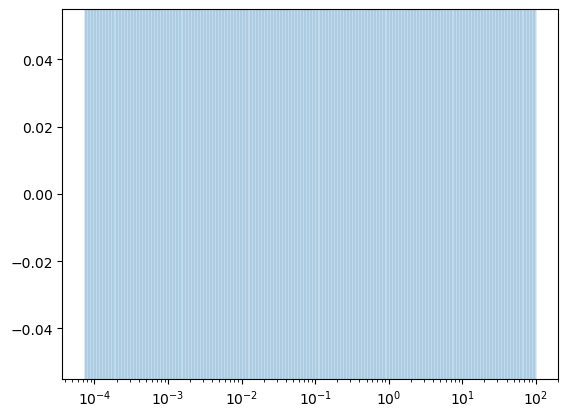

In [9]:
data_CAMB[:,0]

for value in data_CAMB[:,0].tolist():
    plt.axvline(value, lw = 0.2)
plt.semilogx(data_CAMB[0,0],0, lw = 0.2)

In [10]:
# SET THE TARGET AXION FRACTION OF ALL DARK MATTER
TG = 25
M25 = 100

fFDM = TG / 100
# Recall from CAMB the Universe Baryon Density

OmM = 0.31
OmB = 0.02222 / 0.675**2

OmDM = OmM - OmB

OmA = fFDM * OmDM
OmC = OmDM - OmA

print(OmA / OmM, "Axion Mass As Matter Fraction")

BaryonRatio = OmB / (OmC + OmB)

print(f"Baryon Makeup of NBody Particles: {BaryonRatio:.4g}")

import numpy as np
from scipy.interpolate import interp1d
import argparse

input_file_name = f"/Users/fwphys/AxionResearch/Axionyx_Dev22/_axionCAMB-master/GOE_RUN7/G7_M{M25}_F{TG}_transfer_out.dat"
output_file_name = f"/Volumes/FWS500/AXIONYX_D/Transfer_Functions/z{zTG}/G7_{M25:02d}_{TG:03d}"

# Load data from regular CAMB for modification
# MUSIC will be run twice for the mixed case:
# once for the axions particles and once for the cdm particles

# Data from axionCAMB
data_axionCAMB = np.loadtxt(input_file_name)

# Calculate transfer functions
k = data_axionCAMB[:, 0]
Tkc = data_axionCAMB[:, 1]
Tkb = data_axionCAMB[:, 2]
Tkax = data_axionCAMB[:, 6]
Tktot = data_axionCAMB[:, 8]

TkPars = Tkc * (1-BaryonRatio) + Tkb * BaryonRatio

mixed_transfer_cdm = interp1d(k, Tkc, bounds_error=False, fill_value=Tkc[0])
mixed_transfer_baryons = interp1d(k,
                                  Tkb,
                                  bounds_error=False,
                                  fill_value=Tkb[0])

mixed_transfer_particles = interp1d(k,
                                  TkPars,
                                  bounds_error=False,
                                  fill_value=TkPars[0])

mixed_transfer_axions = interp1d(k,
                                 Tkax,
                                 bounds_error=False,
                                 fill_value=Tkax[0])
mixed_transfer_total = interp1d(k,
                                Tktot,
                                bounds_error=False,
                                fill_value=Tktot[0])

### AXIONS ###
factor = mixed_transfer_axions(data_CAMB[:, 0]) / mixed_transfer_cdm(
    data_CAMB[:, 0]
)  # Growth suppression taken as ratio of CDM growth to axion growth

modified_output_axions = data_CAMB.copy()
modified_output_axions[:, 1] = mixed_transfer_axions(data_CAMB[:, 0])
modified_output_axions[:, 6] = mixed_transfer_total(data_CAMB[:, 0])

# Use baryons as the placeholder for DM on a grid
modified_output_axions[:, 2] = mixed_transfer_axions(
    data_CAMB[:, 0])  # baryon transfer function
modified_output_axions[:, 10] *= factor  # Newtonian-gauge CDM velocity
modified_output_axions[:,11] = modified_output_axions[:,10]  # Newtonian-gauge baryon velocity
modified_output_axions[:,12] *=  factor  # relative baryon-CDM velocity (may not be needed)

print(np.isnan(modified_output_axions).any())

np.savetxt(output_file_name + '_axions.dat',
           modified_output_axions,
           delimiter='\t')

### CDM ###
modified_output_cdm = data_CAMB.copy()
modified_output_cdm[:, 1] = mixed_transfer_particles(data_CAMB[:, 0])
modified_output_cdm[:, 6] = mixed_transfer_total(data_CAMB[:, 0])
modified_output_cdm[:,
                    2] = modified_output_cdm[:,
                                             1]  # usually baryons, now replaced with DM on grid
modified_output_cdm[:,
                    11] = modified_output_cdm[:,
                                              10]  # same as above but for velocity

print(np.isnan(modified_output_cdm).any())

np.savetxt(output_file_name + '_cdm.dat', modified_output_cdm, delimiter='\t')

import matplotlib.pyplot as plt

k = data_CAMB[:, 0]

plt.figure()
plt.loglog(k, mixed_transfer_cdm(k), label="T_c")
plt.loglog(k, mixed_transfer_particles(k), label="T_bc")
plt.loglog(k, mixed_transfer_axions(k), label="T_ax")
plt.loglog(k, mixed_transfer_total(k), label="T_tot")
plt.legend()
plt.title("Transfer Functions Used in MUSIC")
plt.xlabel(r"$k\ [h\mathrm{Mpc}^{-1}]$")
plt.show()

0.21067082614274968 Axion Mass As Matter Fraction
Baryon Makeup of NBody Particles: 0.1993


FileNotFoundError: /Users/fwphys/AxionResearch/Axionyx_Dev22/_axionCAMB-master/GOE_RUN7/G7_M100_F25_transfer_out.dat not found.

0.21067082614274968 Axion Mass As Matter Fraction
Baryon Makeup of NBody Particles: 0.1993
False
False


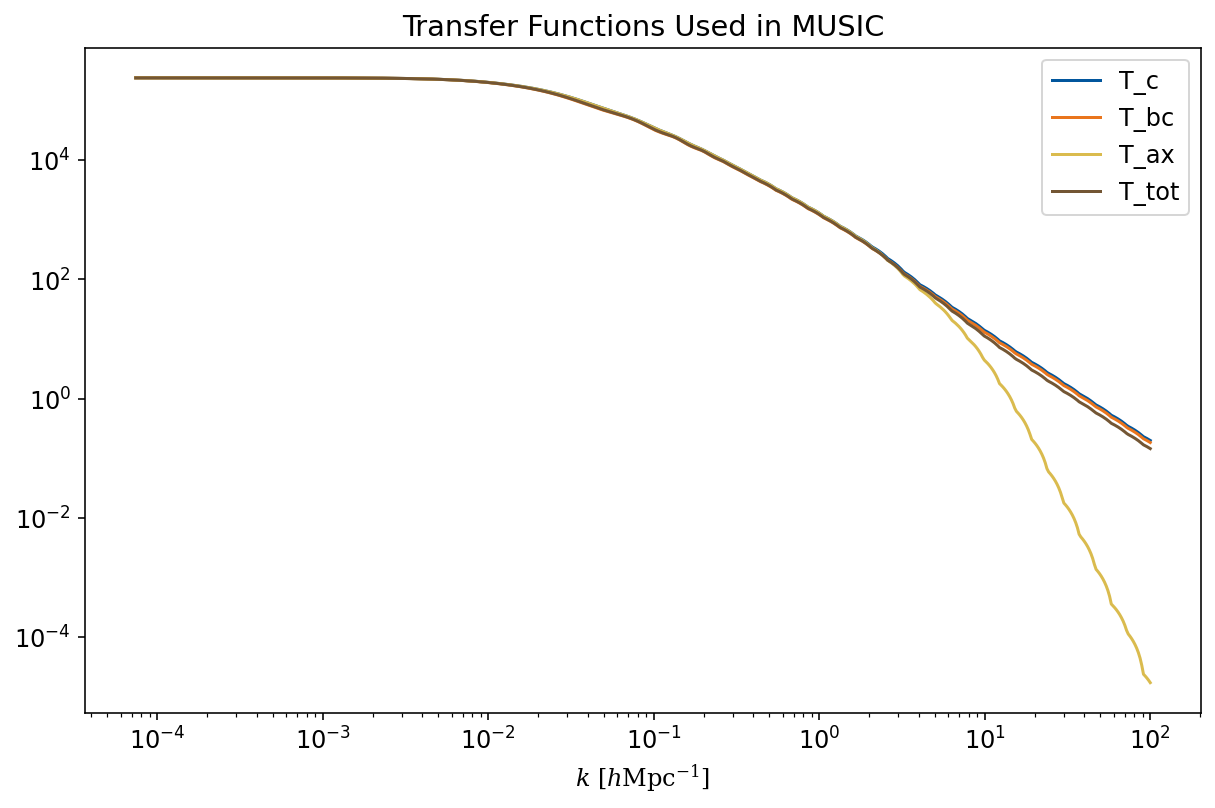

In [15]:
############## FOR HALO MORPHOLOGY PAPER WITH ANDREW
zTG = 99
# SET THE TARGET AXION FRACTION OF ALL DARK MATTER
TG = 25
M25 = 1000

fFDM = TG / 100
# Recall from CAMB the Universe Baryon Density

OmM = 0.31
OmB = 0.02222 / 0.675**2

OmDM = OmM - OmB

OmA = fFDM * OmDM
OmC = OmDM - OmA

print(OmA / OmM, "Axion Mass As Matter Fraction")

BaryonRatio = OmB / (OmC + OmB)

print(f"Baryon Makeup of NBody Particles: {BaryonRatio:.4g}")

import numpy as np
from scipy.interpolate import interp1d
import argparse

input_file_name = f"/Users/fwphys/AxionResearch/Axionyx_Dev22/_axionCAMB-master/GOE_RUN7/G7H_M100_F25_transfer_out.dat"
output_file_name = f"/Volumes/FWS500/AXIONYX_D/Transfer_Functions/z{zTG}/G7_{M25:02d}_{TG:03d}"

# Load data from regular CAMB for modification
# MUSIC will be run twice for the mixed case:
# once for the axions particles and once for the cdm particles

# Data from axionCAMB
data_axionCAMB = np.loadtxt(input_file_name)

# Calculate transfer functions
k = data_axionCAMB[:, 0]
Tkc = data_axionCAMB[:, 1]
Tkb = data_axionCAMB[:, 2]
Tkax = data_axionCAMB[:, 6]
Tktot = data_axionCAMB[:, 8]

TkPars = Tkc * (1-BaryonRatio) + Tkb * BaryonRatio

mixed_transfer_cdm = interp1d(k, Tkc, bounds_error=False, fill_value=Tkc[0])
mixed_transfer_baryons = interp1d(k,
                                  Tkb,
                                  bounds_error=False,
                                  fill_value=Tkb[0])

mixed_transfer_particles = interp1d(k,
                                  TkPars,
                                  bounds_error=False,
                                  fill_value=TkPars[0])

mixed_transfer_axions = interp1d(k,
                                 Tkax,
                                 bounds_error=False,
                                 fill_value=Tkax[0])
mixed_transfer_total = interp1d(k,
                                Tktot,
                                bounds_error=False,
                                fill_value=Tktot[0])

### AXIONS ###
factor = mixed_transfer_axions(data_CAMB[:, 0]) / mixed_transfer_cdm(
    data_CAMB[:, 0]
)  # Growth suppression taken as ratio of CDM growth to axion growth

modified_output_axions = data_CAMB.copy()
modified_output_axions[:, 1] = mixed_transfer_axions(data_CAMB[:, 0])
modified_output_axions[:, 6] = mixed_transfer_total(data_CAMB[:, 0])

# Use baryons as the placeholder for DM on a grid
modified_output_axions[:, 2] = mixed_transfer_axions(
    data_CAMB[:, 0])  # baryon transfer function
modified_output_axions[:, 10] *= factor  # Newtonian-gauge CDM velocity
modified_output_axions[:,11] = modified_output_axions[:,10]  # Newtonian-gauge baryon velocity
modified_output_axions[:,12] *=  factor  # relative baryon-CDM velocity (may not be needed)

print(np.isnan(modified_output_axions).any())

np.savetxt(output_file_name + '_axions.dat',
           modified_output_axions,
           delimiter='\t')

### CDM ###
modified_output_cdm = data_CAMB.copy()
modified_output_cdm[:, 1] = mixed_transfer_particles(data_CAMB[:, 0])
modified_output_cdm[:, 6] = mixed_transfer_total(data_CAMB[:, 0])
modified_output_cdm[:,
                    2] = modified_output_cdm[:,
                                             1]  # usually baryons, now replaced with DM on grid
modified_output_cdm[:,
                    11] = modified_output_cdm[:,
                                              10]  # same as above but for velocity

print(np.isnan(modified_output_cdm).any())

np.savetxt(output_file_name + '_cdm.dat', modified_output_cdm, delimiter='\t')

import matplotlib.pyplot as plt

k = data_CAMB[:, 0]

plt.figure()
plt.loglog(k, mixed_transfer_cdm(k), label="T_c")
plt.loglog(k, mixed_transfer_particles(k), label="T_bc")
plt.loglog(k, mixed_transfer_axions(k), label="T_ax")
plt.loglog(k, mixed_transfer_total(k), label="T_tot")
plt.legend()
plt.title("Transfer Functions Used in MUSIC")
plt.xlabel(r"$k\ [h\mathrm{Mpc}^{-1}]$")
plt.show()

In [12]:
from FWPS import PhDC
import matplotlib as mpl
import matplotlib.font_manager as fm
font_path = fm.findfont(fm.FontProperties(family='Lato'))

plt.style.use('default')

plt.rcParams['axes.labelweight'] = 'bold'

plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams["text.usetex"] = False
plt.rcParams['font.size'] = 12


plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 144

plt.rcParams['image.cmap'] = "magma"

from matplotlib.colors import LinearSegmentedColormap

cyccol = ['#000000', '#ffffff', '#000000']
divcol = ['#003262', '#005b96', '#ffffff', '#d5a756', '#B51700']
divcols = ['#005b96', '#ffffff', '#d5a756']

CycPalette = 'twilight'  #LinearSegmentedColormap.from_list('myCyc', cyccol)

DivPalette = LinearSegmentedColormap.from_list('myDiv', divcol)
DivPaletteS = LinearSegmentedColormap.from_list('myDiv', divcols)

plt.rcParams['axes.prop_cycle'] = mpl.cycler(color=PhDC.ChnArr) 

Colors = PhDC.B2Arr
Palette = PhDC.CMP

In [36]:
k[-1]

np.float64(150.0)

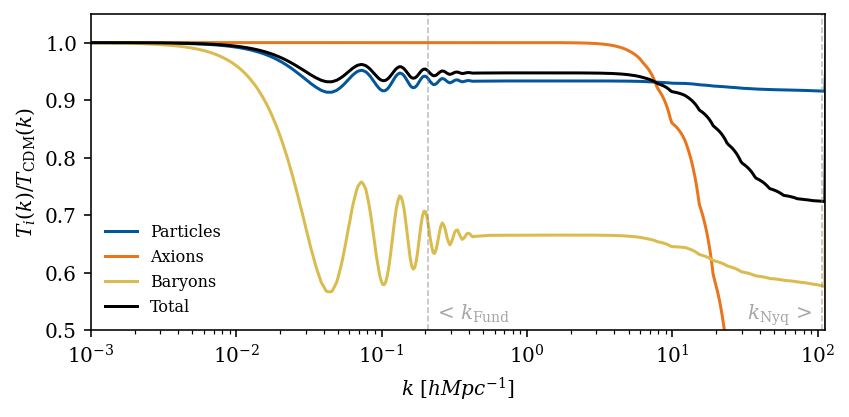

In [49]:
# --- Publication Quality Settings ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "legend.fontsize": 8,
    "savefig.dpi": 300,
    "figure.autolayout": True
})

plt.figure(figsize = (6,3))
plt.xlim(1e-3,k_nyq * 1.05)
plt.semilogx(k, mixed_transfer_particles(k) / mixed_transfer_cdm(k), label="Particles")
plt.semilogx(k, mixed_transfer_axions(k) / mixed_transfer_cdm(k), label="Axions")
plt.semilogx(k, mixed_transfer_baryons(k) / mixed_transfer_cdm(k), label="Baryons")
plt.semilogx(k, mixed_transfer_total(k) / mixed_transfer_cdm(k), label="Total", color = 'k')

# Box fundamental and Nyquist
L_box = 30.0  # Mpc/h
N = 1024
k_fund = 2 * np.pi / L_box
k_nyq = np.pi * N / L_box

plt.axvline(k_fund, color='grey', ls='--', lw=0.8, alpha=0.5)
plt.axvline(k_nyq, color='grey', ls='--', lw=0.8, alpha=0.5)
plt.text(k_fund * 1.15, 0.52, r'< $k_\mathrm{Fund}$', color='grey', fontsize=10, alpha=0.7)
plt.text(k_nyq * 0.85, 0.52, r'$k_\mathrm{Nyq}$ >', color='grey', fontsize=10, alpha=0.7, ha = "right")

plt.ylim(0.5,1.05)
plt.legend(frameon = False)
plt.xlabel(r"$k\ [h Mpc^{-1}]$")
plt.ylabel(r"$T_i(k)/T_\text{CDM}(k)$")

plt.savefig("InitialTF.PDF", bbox_inches="tight")
plt.show()

In [6]:
### SUPPRESSED IC - SINGLE SPECIES CDM RUN ###
# Goal: one particle type that alone reproduces the total suppressed matter power
# T_tot (col 8) already encodes CDM + baryon + axion weighted by their Omega fractions
# MUSIC with CDM-only particles and no baryon transfer will use col 1 as the displacement field

modified_output_suppressed = data_CAMB.copy()

# CDM column gets T_tot — full suppressed matter transfer
modified_output_suppressed[:, 1] = mixed_transfer_total(data_CAMB[:, 0])  # from axionCAMB col 8, already interpolated

# Total transfer column stays as T_tot (consistent, MUSIC may read this too)
modified_output_suppressed[:, 6] = mixed_transfer_total(data_CAMB[:, 0])

# Velocity: CDM velocity field should follow T_tot not T_c
# Scale the existing velocity by T_tot/T_c ratio
vel_ratio = mixed_transfer_total(data_CAMB[:, 0]) / mixed_transfer_cdm(data_CAMB[:, 0])
vel_ratio = np.clip(vel_ratio, 0.0, 1.0)  # T_tot <= T_c always, clip for safety at low k
modified_output_suppressed[:, 10] *= vel_ratio   # CDM velocity

print(np.isnan(modified_output_suppressed).any())
np.savetxt(output_file_name + '_suppressed.dat', modified_output_suppressed, delimiter='\t')

False


In [39]:
BaryonRatio

0.17179344196704263

In [ ]:
################################ SPECIAL CASE FOR ALL ULDM RUN

# SET THE TARGET AXION FRACTION OF ALL DARK MATTER
TG = 100
M25 = 10

fFDM = TG / 100
# Recall from CAMB the Universe Baryon Density

OmM = 0.31
OmB = 0.02222 / 0.675**2

OmDM = OmM - OmB

OmA = fFDM * OmDM
OmC = OmDM - OmA

print(OmA / OmM, "Axion Mass As Matter Fraction")

BaryonRatio = OmB / (OmC + OmB)

print(f"Baryon Makeup of NBody Particles: {BaryonRatio:.4g}")

import numpy as np
from scipy.interpolate import interp1d
import argparse

input_file_name = f"/Volumes/FWS500/AXIONYX_D/Transfer_Functions/G6_M{M25}_F{TG}_transfer_out.dat"
output_file_name = f"/Volumes/FWS500/AXIONYX_D/Transfer_Functions/z{zTG}/G6_{M25:02d}_{TG:03d}"

# Load data from regular CAMB for modification
# MUSIC will be run twice for the mixed case:
# once for the axions particles and once for the cdm particles

# Data from axionCAMB
data_axionCAMB = np.loadtxt(input_file_name)

# Calculate transfer functions
k = data_axionCAMB[:, 0]
Tkc = data_axionCAMB[:, 1]
Tkb = data_axionCAMB[:, 2]
Tkax = data_axionCAMB[:, 6]
Tktot = data_axionCAMB[:, 8]

TkPars = Tkc * (1-BaryonRatio) + Tkb * BaryonRatio

mixed_transfer_cdm = interp1d(k, Tkc, bounds_error=False, fill_value=Tkc[0])
mixed_transfer_baryons = interp1d(k,
                                  Tkb,
                                  bounds_error=False,
                                  fill_value=Tkb[0])

mixed_transfer_particles = interp1d(k,
                                  TkPars,
                                  bounds_error=False,
                                  fill_value=TkPars[0])

mixed_transfer_axions = interp1d(k,
                                 Tkax,
                                 bounds_error=False,
                                 fill_value=Tkax[0])
mixed_transfer_total = interp1d(k,
                                Tktot,
                                bounds_error=False,
                                fill_value=Tktot[0])

### AXIONS ###
factor = mixed_transfer_axions(data_CAMB[:, 0]) / mixed_transfer_cdm(
    data_CAMB[:, 0]
)  # Growth suppression taken as ratio of CDM growth to axion growth

modified_output_axions = data_CAMB.copy()
modified_output_axions[:, 1] = mixed_transfer_axions(data_CAMB[:, 0])
modified_output_axions[:, 6] = mixed_transfer_total(data_CAMB[:, 0])

# Use baryons as the placeholder for DM on a grid
modified_output_axions[:, 2] = mixed_transfer_axions(
    data_CAMB[:, 0])  # baryon transfer function
modified_output_axions[:, 10] *= 1 # factor  # Newtonian-gauge CDM velocity
modified_output_axions[:,11] = modified_output_axions[:,10]  # Newtonian-gauge baryon velocity
modified_output_axions[:,12] *= 1 # factor  # relative baryon-CDM velocity (may not be needed)

print(np.isnan(modified_output_axions).any())

np.savetxt(output_file_name + '_axions_NF.dat',
           modified_output_axions,
           delimiter='\t')

### CDM ###
modified_output_cdm = data_CAMB.copy()
modified_output_cdm[:, 1] = mixed_transfer_particles(data_CAMB[:, 0])
modified_output_cdm[:, 6] = mixed_transfer_total(data_CAMB[:, 0])
modified_output_cdm[:,
                    2] = modified_output_cdm[:,
                                             1]  # usually baryons, now replaced with DM on grid
modified_output_cdm[:,
                    11] = modified_output_cdm[:,
                                              10]  # same as above but for velocity

print(np.isnan(modified_output_cdm).any())

np.savetxt(output_file_name + '_cdm.dat', modified_output_cdm, delimiter='\t')

import matplotlib.pyplot as plt

k = data_CAMB[:, 0]

plt.figure()
plt.loglog(k, mixed_transfer_cdm(k), label="T_c")
plt.loglog(k, mixed_transfer_particles(k), label="T_bc")
plt.loglog(k, mixed_transfer_axions(k), label="T_ax")
plt.loglog(k, mixed_transfer_total(k), label="T_tot")
plt.legend()
plt.title("Transfer Functions Used in MUSIC")
plt.xlabel(r"$k\ [\mathrm{Mpc}^{-1}]$")
plt.show()

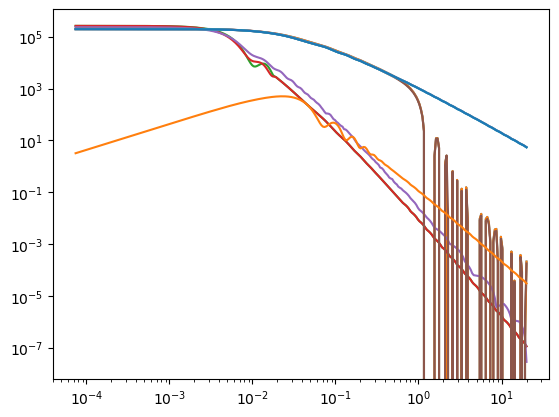

In [17]:
for i in range(1,13,1):
    plt.loglog(k,modified_output_axions[:,i])

In [13]:
import numpy as np

def clean_transfer_function(input_file, output_file):
    # Load your MUSIC transfer function (assuming 2 columns: k, T)
    # Adjust unpack=True if you have more columns (e.g., T_c, T_b, T_g)
    data = np.loadtxt(input_file)
    k = data[:, 0]
    
    # Process each transfer column
    cleaned_data = np.zeros_like(data)
    cleaned_data[:, 0] = k
    
    for col in range(1, data.shape[1]):
        T = data[:, col]
        
        # 1. Replace NaNs or Infs if any slipped in
        T = np.nan_to_num(T, nan=1e-20, posinf=1e-20, neginf=1e-20)
        
        # 2. Enforce a tiny floor. MUSIC's log-interpolation 
        # will fail if it hits a zero in those axion wiggles.
        T = np.maximum(T, 1e-25)
        
        # 3. Flatten the very low-k behavior.
        # Physics: T(k) must be constant at large scales (k -> 0).
        # We force the first 5 bins to be equal to the first value.
        T[:5] = T[0]
        
        cleaned_data[:, col] = T

    # Save with high precision to avoid rounding errors in MUSIC
    np.savetxt(output_file, cleaned_data, fmt='%.12e', delimiter='  ')
    print(f"Cleaned transfer function saved to: {output_file}")

# Usage
clean_transfer_function(output_file_name + '_axions_NF.dat', output_file_name + '_axions_NFC.dat')

Cleaned transfer function saved to: /Volumes/FWS500/AXIONYX_D/Transfer_Functions/z120/G6_10_100_axions_NFC.dat


0.06741466436567989
Baryon Makeup of NBody Particles: 0.1687
102.496
20.0
False
False
0.06741466436567989
Baryon Makeup of NBody Particles: 0.1687
102.496
20.0
False
False
0.06741466436567989
Baryon Makeup of NBody Particles: 0.1687
102.496
20.0
False
False
0.08426833045709987
Baryon Makeup of NBody Particles: 0.1718
102.496
20.0
False
False
0.08426833045709987
Baryon Makeup of NBody Particles: 0.1718
102.496
20.0
False
False
0.08426833045709987
Baryon Makeup of NBody Particles: 0.1718
102.496
20.0
False
False
0.10112199654851983
Baryon Makeup of NBody Particles: 0.175
102.496
20.0
False
False
0.10112199654851983
Baryon Makeup of NBody Particles: 0.175
102.496
20.0
False
False
0.10112199654851983
Baryon Makeup of NBody Particles: 0.175
102.496
20.0
False
False


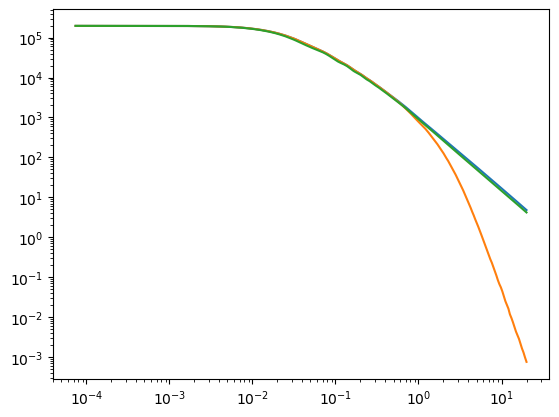

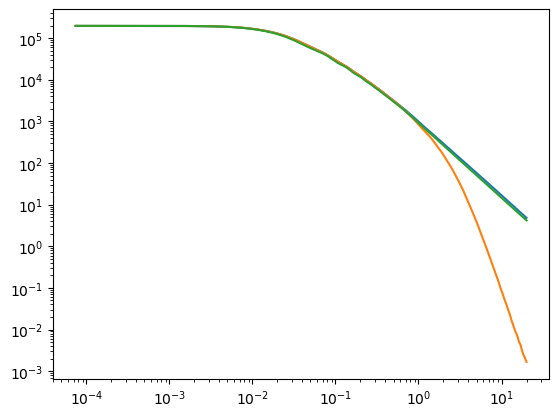

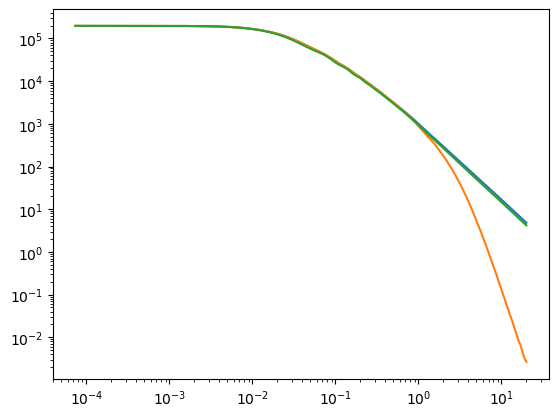

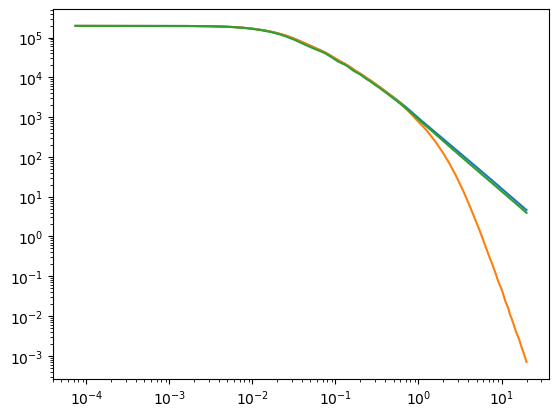

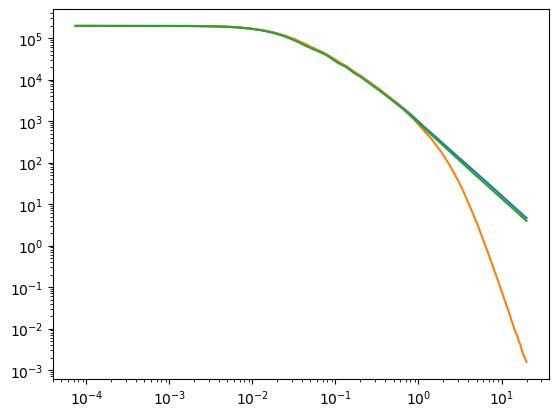

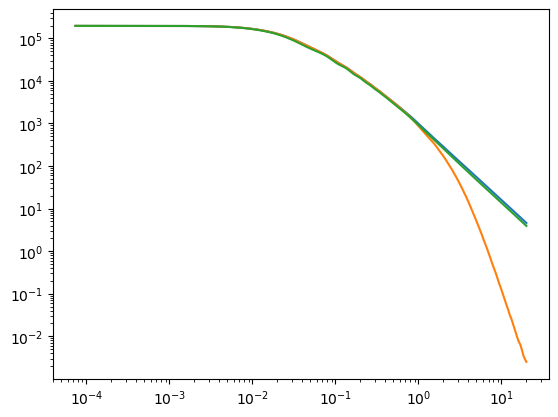

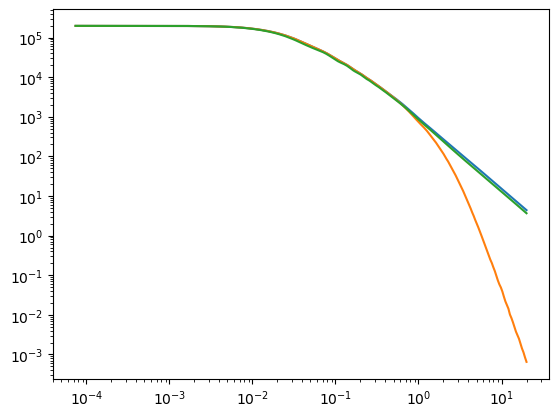

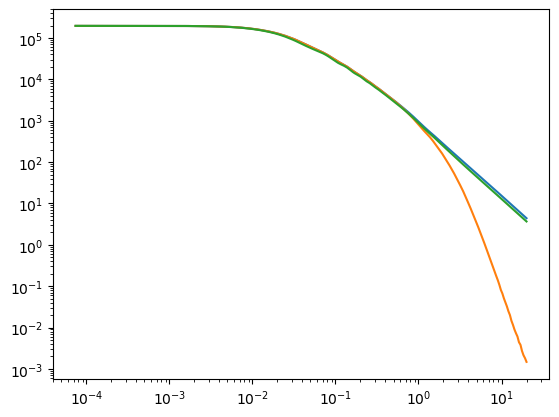

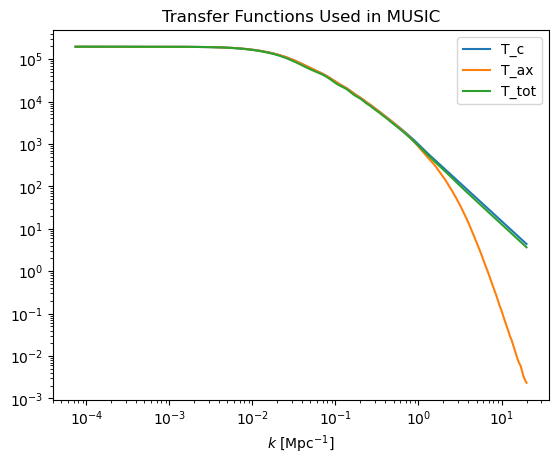

In [8]:
TGL = [8,10,12]
M25L = [6,8,10]

for TG in TGL:
    for M25 in M25L:
                # SET THE TARGET AXION FRACTION OF ALL DARK MATTER

        fFDM = TG / 100
        # Recall from CAMB the Universe Baryon Density

        OmM = 0.31
        OmB = 0.02222 / 0.675**2

        OmDM = OmM - OmB

        OmA = fFDM * OmDM
        OmC = OmDM - OmA

        print(OmA / OmM)

        BaryonRatio = OmB / (OmC + OmB)

        print(f"Baryon Makeup of NBody Particles: {BaryonRatio:.4g}")

        import numpy as np
        from scipy.interpolate import interp1d
        import argparse

        input_file_name = f"/Volumes/FWS500/AXIONYX_D/Transfer_Functions/G6_M{M25}_F{TG}_transfer_out.dat"
        output_file_name = f"/Volumes/FWS500/AXIONYX_D/Transfer_Functions/z{zTG}/G6_{M25:02d}_{TG:03d}"

        # Load data from regular CAMB for modification
        # MUSIC will be run twice for the mixed case:
        # once for the axions particles and once for the cdm particles

        # Data from axionCAMB
        data_axionCAMB = np.loadtxt(input_file_name)

        # Calculate transfer functions
        k = data_axionCAMB[:, 0]
        Tkc = data_axionCAMB[:, 1]
        Tkb = data_axionCAMB[:, 2]
        Tkax = data_axionCAMB[:, 6]
        Tktot = data_axionCAMB[:, 8]

        TkPars = Tkc * (1-BaryonRatio) + Tkb * BaryonRatio

        print(np.max(k))
        print(np.max(data_CAMB[:, 0]))

        mixed_transfer_cdm = interp1d(k, Tkc, bounds_error=False, fill_value=Tkc[0])
        mixed_transfer_baryons = interp1d(k,
                                          Tkb,
                                          bounds_error=False,
                                          fill_value=Tkb[0])

        mixed_transfer_particles = interp1d(k,
                                          TkPars,
                                          bounds_error=False,
                                          fill_value=TkPars[0])

        mixed_transfer_axions = interp1d(k,
                                         Tkax,
                                         bounds_error=False,
                                         fill_value=Tkax[0])
        mixed_transfer_total = interp1d(k,
                                        Tktot,
                                        bounds_error=False,
                                        fill_value=Tktot[0])

        ### AXIONS ###
        factor = mixed_transfer_axions(data_CAMB[:, 0]) / mixed_transfer_cdm(
            data_CAMB[:, 0]
        )  # Growth suppression taken as ratio of CDM growth to axion growth

        modified_output_axions = data_CAMB.copy()
        modified_output_axions[:, 1] = mixed_transfer_axions(data_CAMB[:, 0])
        modified_output_axions[:, 6] = mixed_transfer_total(data_CAMB[:, 0])

        # Use baryons as the placeholder for DM on a grid
        modified_output_axions[:, 2] = mixed_transfer_axions(
            data_CAMB[:, 0])  # baryon transfer function
        modified_output_axions[:, 10] *= factor  # Newtonian-gauge CDM velocity
        modified_output_axions[:,11] = modified_output_axions[:,10]  # Newtonian-gauge baryon velocity
        modified_output_axions[:,12] *= factor  # relative baryon-CDM velocity (may not be needed)

        print(np.isnan(modified_output_axions).any())

        np.savetxt(output_file_name + '_axions.dat',
                   modified_output_axions,
                   delimiter='\t')

        ### CDM ###
        modified_output_cdm = data_CAMB.copy()
        modified_output_cdm[:, 1] = mixed_transfer_particles(data_CAMB[:, 0])
        modified_output_cdm[:, 6] = mixed_transfer_total(data_CAMB[:, 0])
        modified_output_cdm[:,
                            2] = modified_output_cdm[:,
                                                     1]  # usually baryons, now replaced with DM on grid
        modified_output_cdm[:,
                            11] = modified_output_cdm[:,
                                                      10]  # same as above but for velocity

        print(np.isnan(modified_output_cdm).any())

        np.savetxt(output_file_name + '_cdm.dat', modified_output_cdm, delimiter='\t')
       

        import matplotlib.pyplot as plt

        k = data_CAMB[:, 0]

        plt.figure()
        plt.loglog(k, mixed_transfer_cdm(k), label="T_c")
        plt.loglog(k, mixed_transfer_axions(k), label="T_ax")
        plt.loglog(k, mixed_transfer_total(k), label="T_tot")
        
        
plt.legend()
plt.title("Transfer Functions Used in MUSIC")
plt.xlabel(r"$k\ [\mathrm{Mpc}^{-1}]$")
plt.show()

0.21067082614274968
Baryon Makeup of NBody Particles: 0.1993
102.496
20.0
False
False


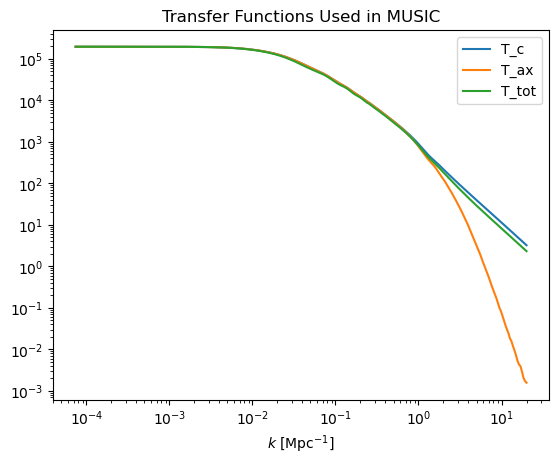

In [9]:
TG = 25
M25 = 10
        # SET THE TARGET AXION FRACTION OF ALL DARK MATTER

fFDM = TG / 100
# Recall from CAMB the Universe Baryon Density

OmM = 0.31
OmB = 0.02222 / 0.675**2

OmDM = OmM - OmB

OmA = fFDM * OmDM
OmC = OmDM - OmA

print(OmA / OmM)

BaryonRatio = OmB / (OmC + OmB)

print(f"Baryon Makeup of NBody Particles: {BaryonRatio:.4g}")

import numpy as np
from scipy.interpolate import interp1d
import argparse

input_file_name = f"/Volumes/FWS500/AXIONYX_D/Transfer_Functions/G6_M{M25}_F{TG}_transfer_out.dat"
output_file_name = f"/Volumes/FWS500/AXIONYX_D/Transfer_Functions/z{zTG}/G6_{M25:02d}_{TG:03d}"

# Load data from regular CAMB for modification
# MUSIC will be run twice for the mixed case:
# once for the axions particles and once for the cdm particles

# Data from axionCAMB
data_axionCAMB = np.loadtxt(input_file_name)

# Calculate transfer functions
k = data_axionCAMB[:, 0]
Tkc = data_axionCAMB[:, 1]
Tkb = data_axionCAMB[:, 2]
Tkax = data_axionCAMB[:, 6]
Tktot = data_axionCAMB[:, 8]

TkPars = Tkc * (1-BaryonRatio) + Tkb * BaryonRatio

print(np.max(k))
print(np.max(data_CAMB[:, 0]))

mixed_transfer_cdm = interp1d(k, Tkc, bounds_error=False, fill_value=Tkc[0])
mixed_transfer_baryons = interp1d(k,
                                  Tkb,
                                  bounds_error=False,
                                  fill_value=Tkb[0])

mixed_transfer_particles = interp1d(k,
                                  TkPars,
                                  bounds_error=False,
                                  fill_value=TkPars[0])

mixed_transfer_axions = interp1d(k,
                                 Tkax,
                                 bounds_error=False,
                                 fill_value=Tkax[0])
mixed_transfer_total = interp1d(k,
                                Tktot,
                                bounds_error=False,
                                fill_value=Tktot[0])

### AXIONS ###
factor = mixed_transfer_axions(data_CAMB[:, 0]) / mixed_transfer_cdm(
    data_CAMB[:, 0]
)  # Growth suppression taken as ratio of CDM growth to axion growth

modified_output_axions = data_CAMB.copy()
modified_output_axions[:, 1] = mixed_transfer_axions(data_CAMB[:, 0])
modified_output_axions[:, 6] = mixed_transfer_total(data_CAMB[:, 0])

# Use baryons as the placeholder for DM on a grid
modified_output_axions[:, 2] = mixed_transfer_axions(
    data_CAMB[:, 0])  # baryon transfer function
modified_output_axions[:, 10] *= factor  # Newtonian-gauge CDM velocity
modified_output_axions[:,11] = modified_output_axions[:,10]  # Newtonian-gauge baryon velocity
modified_output_axions[:,12] *= factor  # relative baryon-CDM velocity (may not be needed)

print(np.isnan(modified_output_axions).any())

np.savetxt(output_file_name + '_axions.dat',
           modified_output_axions,
           delimiter='\t')

### CDM ###
modified_output_cdm = data_CAMB.copy()
modified_output_cdm[:, 1] = mixed_transfer_particles(data_CAMB[:, 0])
modified_output_cdm[:, 6] = mixed_transfer_total(data_CAMB[:, 0])
modified_output_cdm[:,
                    2] = modified_output_cdm[:,
                                             1]  # usually baryons, now replaced with DM on grid
modified_output_cdm[:,
                    11] = modified_output_cdm[:,
                                              10]  # same as above but for velocity

print(np.isnan(modified_output_cdm).any())

np.savetxt(output_file_name + '_cdm.dat', modified_output_cdm, delimiter='\t')

import matplotlib.pyplot as plt

k = data_CAMB[:, 0]

plt.figure()
plt.loglog(k, mixed_transfer_cdm(k), label="T_c")
plt.loglog(k, mixed_transfer_axions(k), label="T_ax")
plt.loglog(k, mixed_transfer_total(k), label="T_tot")


plt.legend()
plt.title("Transfer Functions Used in MUSIC")
plt.xlabel(r"$k\ [\mathrm{Mpc}^{-1}]$")
plt.show()